# Targeted subgroup analysis: actors subgroup

1. Cleaning/ validation steps
2. Overall response distribution
3. Counts and proportions by condition
    - Goal Type
    - Agency
    - Goal Type x Agency

Import libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read data

In [37]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

## 1. Cleaning/ validation steps

Subset data for subgroup: 

- Proficiency: Per_Level_Label = ["B2.1", "B2.2", "C1"]
- Exposure: Prof_Use_Label = "Yes"

In [38]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

Subgroup validation

In [39]:
subgroup.shape

(198, 31)

In [40]:
subgroup.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'Response_Full', 'EXP', 'n',
       'Age', 'Gender', 'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents',
       'Multi_Kno', 'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use',
       'Motivation', 'Distractor', 'GN_Score', 'Difficulty', 'Kno_Level_Label',
       'Per_Level_Label', 'Prof_Need_Label', 'Prof_Use_Label'],
      dtype='str')

In [41]:
subgroup.duplicated().sum()

np.int64(0)

In [42]:
subgroup.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,Response_Full,...,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty,Kno_Level_Label,Per_Level_Label,Prof_Need_Label,Prof_Use_Label
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes


Slice data by focus: "actors" or "self-focus"

In [43]:
subgroup_actors = subgroup[subgroup["Focus"] == "I"].copy()

## 2. Overall response distribution for Actors

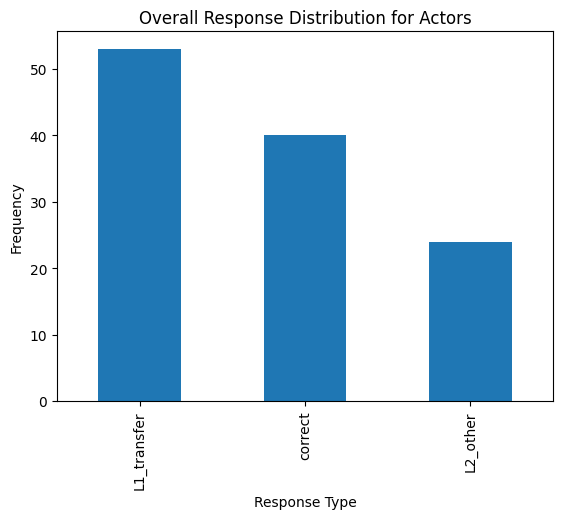

In [44]:
subgroup_actors["Response_Full"].value_counts().plot(kind="bar")

plt.title("Overall Response Distribution for Actors") 
plt.xlabel("Response Type") 
plt.ylabel("Frequency")
plt.show()

The actors subgroup keeps providing a coherent story. Transfer responses still dominate but correct responses are higher compared to the overall subgroup.

## 3. Counts and proportions by condition

**Responses by Goal Type for actors:**

- Counts
- Proportions 
- Proportions plot

In [45]:
goal_response_counts_a = pd.crosstab(
    subgroup_actors["Goal_Type"],
    subgroup_actors["Response_Full"],
    dropna=False,
    margins=True
)

goal_response_counts_a

Response_Full,L1_transfer,L2_other,correct,NaN,All
Goal_Type,,,,,
goal_frequent,13,10,16,1,40
goal_non_frequent,18,9,13,0,40
no_goal,22,5,11,2,40
All,53,24,40,3,120


In [46]:
goal_response_props_a = pd.crosstab(
    subgroup_actors["Goal_Type"],
    subgroup_actors["Response_Full"],
    dropna = False,
    normalize="index"
)

goal_response_props_a

Response_Full,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,0.325,0.250,0.400,0.025
goal_non_frequent,0.450,0.225,0.325,0.000
no_goal,0.550,0.125,0.275,0.050


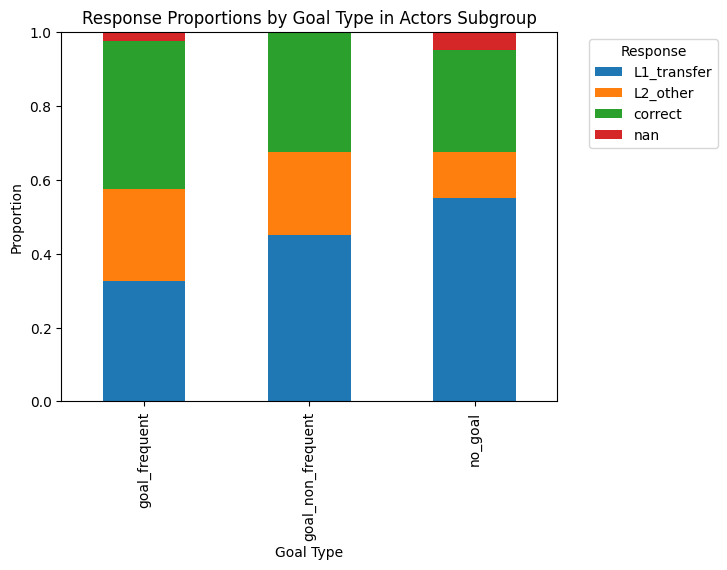

In [47]:
goal_response_props_a.plot(kind = "bar", stacked = True)

plt.title("Response Proportions by Goal Type in Actors Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


Considering goal type:

- goal_frequent seems to be the best envrionment for correct responses and shows the lowest proportion of transfer. 

- as expected, transfer increases when compared to goal-frequent while correct responses distribution decreases. 

- no_goal shows the highest transfer and the lowest corect responses.

This could point to goal structure as something that seems to matter for actors; however, agency is expected to add to the picture. 

Something worth considering after further analysis is the fact that the 3 remaining null responses (avoidance) from the original counts (11) once the subrgroup was targeted belong to the actors subgroup. 

**Responses by Agent for actors:**

- Counts
- Proportions 
- Proportions plot

In [48]:
agent_response_counts_a = pd.crosstab(
    subgroup_actors["Agent"],
    subgroup_actors["Response_Full"],
    dropna=False,
    margins=True
)

agent_response_counts_a

Response_Full,L1_transfer,L2_other,correct,NaN,All
Agent,,,,,
0,26,19,24,3,72
1,27,5,16,0,48
All,53,24,40,3,120


In [49]:
agent_response_props_a = pd.crosstab(
    subgroup_actors["Agent"],
    subgroup_actors["Response_Full"],
    dropna= False,
    normalize="index"
)

agent_response_props_a

Response_Full,L1_transfer,L2_other,correct,NaN
Agent,,,,
0,0.361111,0.263889,0.333333,0.041667
1,0.562500,0.104167,0.333333,0.000000


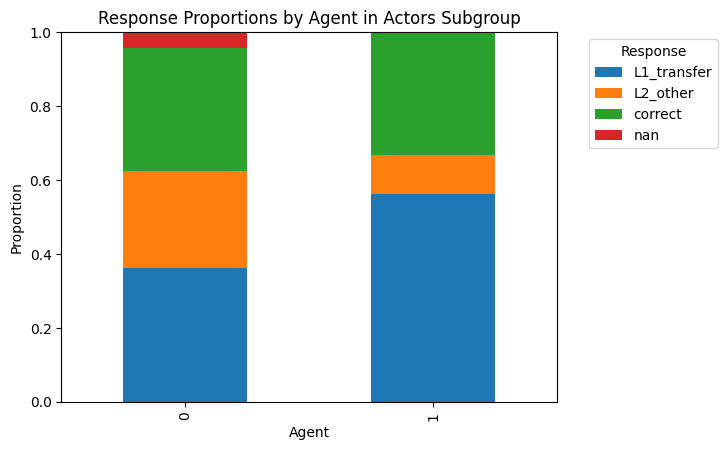

In [50]:
agent_response_props_a.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Agent in Actors Subgroup")
plt.xlabel("Agent")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

As expected, L2 alternatives almost dissapears with an explicit agent and null response distribution appears when there isn't an explicit agent. On the other hand, explicit agency does not help correct resolution for actors; what it does is increase the proportion of transfer responses.

**Responses by Goal Type and Agent for actors:**

- Counts
- Proportions 
- Proportions plot

In [51]:
goal_agent_response_counts_a = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Agent"]],
    subgroup_actors["Response_Full"],
    dropna=False,
    margins=True
)

goal_agent_response_counts_a

Response_Full            L1_transfer  L2_other  correct  NaN  All
Goal_Type         Agent                                          
goal_frequent     0                6         8        9    1   24
                  1                7         2        7    0   16
goal_non_frequent 0                7         8        9    0   24
                  1               11         1        4    0   16
no_goal           0               13         3        6    2   24
                  1                9         2        5    0   16
All                               53        24       40    3  120

In [52]:
goal_agent_response_props_a = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Agent"]],
    subgroup_actors["Response_Full"],
    dropna=False,
    normalize="index"
)

goal_agent_response_props_a

Response_Full            L1_transfer  L2_other  correct       NaN
Goal_Type         Agent                                          
goal_frequent     0         0.250000  0.333333   0.3750  0.041667
                  1         0.437500  0.125000   0.4375  0.000000
goal_non_frequent 0         0.291667  0.333333   0.3750  0.000000
                  1         0.687500  0.062500   0.2500  0.000000
no_goal           0         0.541667  0.125000   0.2500  0.083333
                  1         0.562500  0.125000   0.3125  0.000000

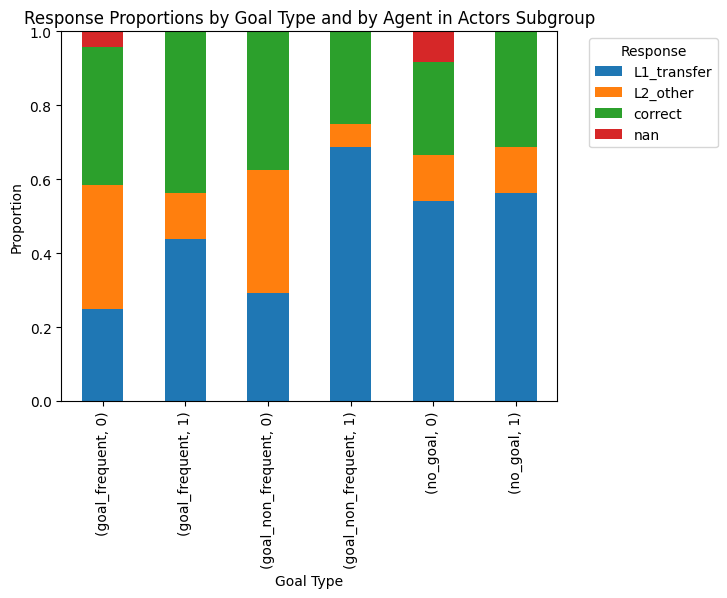

In [53]:
goal_agent_response_props_a.plot(kind="bar", stacked= True)

plt.title("Response Proportions by Goal Type and by Agent in Actors Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

- goal_non_frequent and explicit agency shows the highest proportion of transfer at almost 0.69 -very high. This really support the ideat that, for actors, explicit liability plus a non_frequent emotionally loaded goal structure creates and environment where transfer becomes the dominant resolution strategy. 

- In contrast, goal_frequent and explicit agency show the highest proportion of correct responses among conditions at almost 0.44 but tied with transfer. 

- goal_non_frequent and goal_frequent without explicit agency's response distribution are remarkably similar. The only difference comes from the expected agent = 0 null reponse distribution when goal frequent which is added not to correct or L2 alternatives but to transfer responses when the goal is not frequent. 

- With this, it looks like, for actors, when the context is coherent enough, explicit agency can support target restructuring; however, when the goal is conceptually heavy, explicit agency seems to push the system towards transfer.

- no-goal keeps behaving differently to the other 2 types of goals. In fact, it is clearer now that whatever resoluion strategy actors apply has nothing to do with agency.